2.1. Predicting Price with Size

In [1]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import VimeoVideo
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.utils.validation import check_is_fitted

warnings.simplefilter(action="ignore", category=FutureWarning)

Prepare Data
Import
One way to automate the data importing and cleaning process is by writing a function. This will make sure that all our data undergoes the same process,
and that our analysis is easily reproducible — something that's very important in science in general and data science in particular.

Task 2.1.1: Write a function named wrangle that takes a file path as an argument and returns a DataFrame.

What's a function?
Write a function in Python.

In [10]:
def wrangle(filepath):
    df = pd.read_csv(filepath)
    #subset to properties in "Capital Federal"
    mask_ba = df["place_with_parent_names"].str.contains("Capital Federal")
    #subset ot "apartments"
    mask_apt = df["property_type"] == "apartment"
    #subset of properties "price_aprox_usd" , 400000
    mask_price = df["price_aprox_usd"] <= 400000
    df= df[mask_ba & mask_apt & mask_price]
    #remove outliner of "surface_covered_in_m2"
    low, high = df ["surface_covered_in_m2"].quantile([0.1, 0.9])
    mask_area = df ["surface_covered_in_m2"].between (low, high)
    df = df[mask_area]
    return df

Task 2.1.2: Use your wrangle function to create a DataFrame df from the CSV file data/buenos-aires-real-estate-1.csv.

In [13]:
df = wrangle("../data/raw/buenos-aires-real-estate-1.csv")
print("df shape:", df.shape)
df.head()

df shape: (1343, 16)


,operation,property_type,place_with_parent_names,lat-lon,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,floor,rooms,expenses,properati_url
4,sell,apartment,|Argentina|Capital Federal|Chacarita|,"-34.5846508988,-58.4546932614",129000.0,USD,1955949.6,129000.0,76.0,70.0,1697.368421,1842.857143,NaN,NaN,NaN,http://chacarita.properati.com.ar/10qlv_venta_...
9,sell,apartment,|Argentina|Capital Federal|Villa Luro|,"-34.6389789,-58.500115",87000.0,USD,1319128.8,87000.0,48.0,42.0,1812.500000,2071.428571,NaN,NaN,NaN,http://villa-luro.properati.com.ar/12m82_venta...
29,sell,apartment,|Argentina|Capital Federal|Caballito|,"-34.615847,-58.459957",118000.0,USD,1789163.2,118000.0,NaN,54.0,NaN,2185.185185,NaN,2.0,NaN,http://caballito.properati.com.ar/11wqh_venta_...
40,sell,apartment,|Argentina|Capital Federal|Constitución|,"-34.6252219,-58.3823825",57000.0,USD,864256.8,57000.0,42.0,42.0,1357.142857,1357.142857,5.0,2.0,364.0,http://constitucion.properati.com.ar/k2f0_vent...
41,sell,apartment,|Argentina|Capital Federal|Once|,"-34.6106102,-58.4125107",90000.0,USD,1364616.0,90000.0,57.0,50.0,1578.947368,1800.000000,NaN,3.0,450.0,http://once.properati.com.ar/suwa_venta_depart...


For this project, we want to build a model for apartments in Buenos Aires proper ("Capital Federal") that cost less than
$400,000. Looking at the first five rows of our DataFrame, we can already see that there properties that fall outside those parameters. 
So our first cleaning task is to remove those observations from our dataset. Since we're using a function to import and clean our data, 
we'll need to make changes there.

Task 2.1.3: Add to your wrangle function so that the DataFrame it returns only includes apartments in Buenos Aires ("Capital Federal") that cost
less than $400,000 USD. Then recreate df from data/buenos-aires-real-estate-1.csv by re-running the cells above.

Subset a DataFrame with a mask using pandas.
To check your work, df should no have no more than 1,781 observations.

Explore
We saw in the previous project that property size is an important factor in determining price. With that in mind, 
let's look at the distribution of apartment sizes in our dataset.

Task 2.1.4: Create a histogram of "surface_covered_in_m2". Make sure that the x-axis has the label "Area [sq meters]" and the plot has the title "Distribution of Apartment Sizes".

A histogram is a graph that shows the frequency distribution of numerical data. In addition to helping us understand frequency, histograms are also useful for detecting outliers.
Create a histogram using Matplotlib.

Text(0.5, 1.0, 'Distribution of Apartment Sizes')

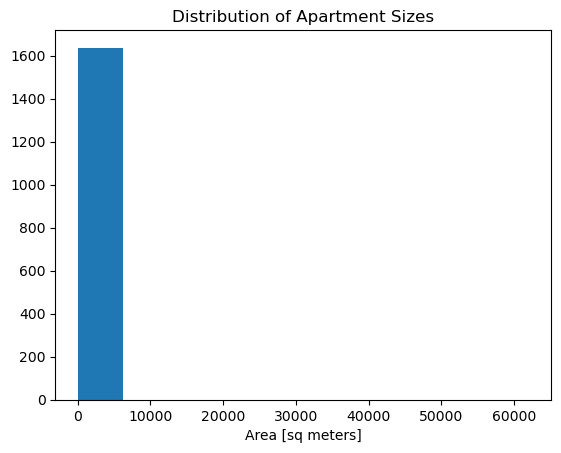

In [8]:
plt.hist(df["surface_covered_in_m2"])
plt.xlabel("Area [sq meters]" )
plt.title("Distribution of Apartment Sizes")

In [ ]:
When you see a histogram like the one above, it suggests that there are outliers in your dataset. This can affect model performance — especially in 
the sorts of linear models we'll learn about in this project. To confirm, let's look at the summary statistics for the "surface_covered_in_m2" feature.

In [ ]:
Task 2.1.5: Calculate the summary statistics for df using the describe method.

What's skewed data?

For any given activity, there is a range of probable outcomes. All other things being equal, we would expect most of the outcomes to fall in the 
middle of the possible range, with the number of outcomes diminishing on either side of the peak. In statistics, this is known as a normal distribution,
but you may have heard it called a bell curve, because it looks like a bell.

In [9]:
df.describe()["surface_covered_in_m2"]

count     1638.000000
mean        98.047009
std       1531.659615
min          0.000000
25%         38.000000
50%         50.000000
75%         74.000000
max      62034.000000
Name: surface_covered_in_m2, dtype: float64

The statistics above confirm what we suspected. While most of the apartments in our dataset are smaller that 73 square meters, there are some that 
are several thousand square meters. The best thing to do is to change our wrangle function and remove them from the dataset.

Task 2.1.6: Add to your wrangle function so that it removes observations that are outliers in the "surface_covered_in_m2" column. Specifically, 
all observations should fall between the 0.1 and 0.9 quantiles for "surface_covered_in_m2".                                                                                
Quantiles allow you to summarize the distribution of numerical values in a series. The n'th quantile divides an ordered series into n portions, 
each with the same number of entries. The boundaries between these portions are known as quantiles.

In [11]:
low, high = df ["surface_covered_in_m2"].quantile([0.1, 0.9])
mask_area = df ["surface_covered_in_m2"].between (low, high)
df = df[mask_area]

Task 2.1.7: Create a scatter plot that shows price ("price_aprox_usd") vs area ("surface_covered_in_m2") in our dataset. Make sure to label your
x-axis "Area [sq meters]" and your y-axis "Price [USD]".
    
A scatter plot is a graph that uses dots to represent values for two different numeric variables. The position of each dot on the horizontal and 
vertical axis indicates values for an individual data point. Scatter plots are used to observe relationships between variables, and are especially 
useful if you're looking for correlations.

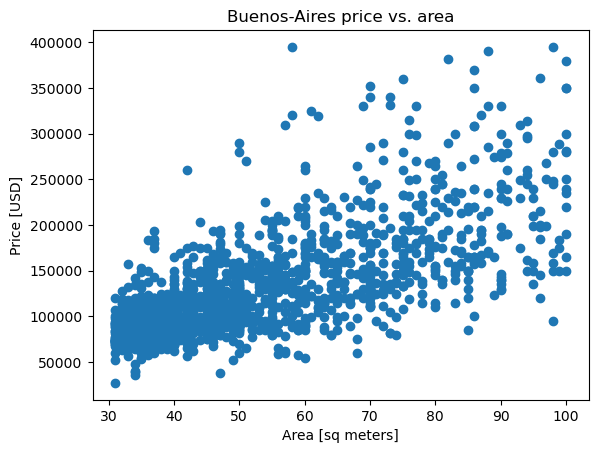

In [14]:
plt.scatter(x= df["surface_covered_in_m2"], y= df["price_aprox_usd"])
plt.xlabel("Area [sq meters]")
plt.ylabel("Price [USD]")
plt.title("Buenos-Aires price vs. area");

This plot suggests that there's a moderate positive correlation between apartment price and size. This means that if thing we want to predict is price,
size will be a good feature to include.

Split
A key part in any model-building project is separating your target (the thing you want to predict) from your features (the information your model will 
use to make its predictions). Since this is our first model, we'll use just one feature: apartment size.

In [ ]:
Task 2.1.8: Create the feature matrix named X_train, which you'll use to train your model. It should contain one feature only: 
["surface_covered_in_m2"]. Remember that your feature matrix should always be two-dimensional.

In machine learning, a regression problem is when you need to build a model that's going to predict a continuous, numerical value, like the sale
price of an apartment. One of the models that you can use for regression problems is called linear regression. In it's simplest form, we fit a model
that will predict a single output variable (called a target vector) as a linear function of a single input variable (called a feature matrix).

Speaking mathematically, if we have input data points x and corresponding measured output y, then we find parameters m and b such that y= m*x+b for our measured 
data points. We then use the fitted values of m and b to predict values of y for new values of x.

In [15]:
features = ["surface_covered_in_m2"]
X_train= df[features]
X_train.head()

,surface_covered_in_m2
4,70.0
9,42.0
29,54.0
40,42.0
41,50.0


In [ ]:
Task 2.1.9: Create the target vector named y_train, which you'll use to train your model. Your target should be "price_aprox_usd". Remember that, in
most cases, your target vector should be one-dimensional.
    

In [16]:
target = "price_aprox_usd"
y_train= df[target]
y_train.shape

(1343,)

In [ ]:
Build Model

In [ ]:
Baseline

The first step in building a model is baselining. To do this, ask yourself how you will know if the model you build is performing well?
" One way to think about this is to see how a "dumb" model would perform on the same data. Some people also call this a naïve or baseline model, 
but it's always a model makes only one prediction — in this case, it predicts the same price regardless of an apartment's size. So let's start by 
figuring out what our baseline model's prediction should be.

In [ ]:
Task 2.1.10: Calculate the mean of your target vector y_train and assign it to the variable y_mean.

In [17]:
y_mean = y_train.mean()
y_mean

np.float64(135527.83871928515)

In [ ]:
Task 2.1.11: Create a list named y_pred_baseline that contains the value of y_mean repeated so that it's the same length at y.

In [18]:
y_pred_baseline = [y_mean] * len(y_train)


In [20]:
Task 2.1.12: Add a line to the plot below that shows the relationship between the observations X_train and our dumb model's predictions y_pred_baseline.
Be sure that the line color is orange, and that it has the label "Baseline Model".

pandas.core.series.Series

Line plots demonstrate relationships between two variables which have some order. If we look at the data in buenos-aires-real-estate-1.csv, a scatter 
plot shows us that there's a relationship between "surface_covered_in_m2" and "price_aprox_usd".    

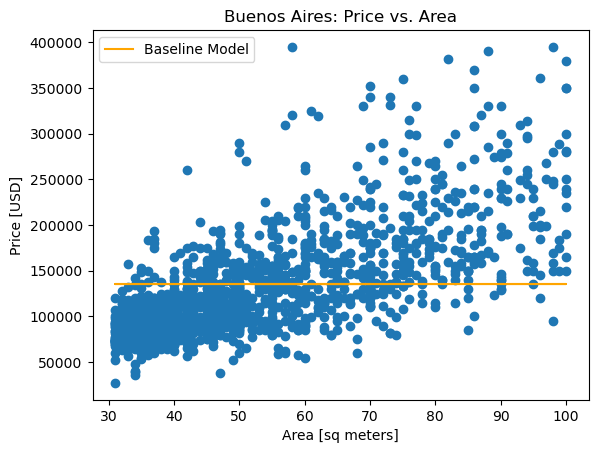

In [19]:
plt.plot(X_train["surface_covered_in_m2"], y_pred_baseline, color="orange", label= "Baseline Model")
plt.scatter(X_train, y_train)
plt.xlabel("Area [sq meters]")
plt.ylabel("Price [USD]")
plt.title("Buenos Aires: Price vs. Area")
plt.legend();

Looking at this visualization, it seems like our baseline model doesn't really follow the trend in the data. But, as a data scientist, you can't depend
only on a subjective plot to evaluate a model. You need an exact, mathematically calculate performance metric. There are lots of performance metrics, 
but the one we'll use here is the mean absolute error

In [ ]:
Task 2.1.13: Calculate the baseline mean absolute error for your predictions in y_pred_baseline as compared to the true targets in y.

Performance Metrics
In statistics, an error is the difference between a measurement and reality. There may not be any difference at all, but there's usually something not 
quite right, and we need to account for that in our model. To do that, we need to figure out the mean absolute error (MAE). Absolute error is the error in a single measurement, and mean absolute error is the average error over the course of several measurements.
Imagine that you're buying some bananas. The store charges for fruit based on weight, so you put your bananas on a scale before you head off to pay for
them. The scale says they weigh 1.2 kilos, but your innate sense of weight tells you that they actually weight 0.9 kilos. The absolute error in that 
measurement would be 0.3 kilos. It can go the other way too: maybe you know the bananas weight 1.2 kilos, but the scale says they were 0.9 kilos. In 
that case, the absolute error would still be 0.3 kilos, because even though the numerical difference is -0.3, absolute values are always positive; all
you have to do is disregard the - sign.

Let's keep going: you're sure the bananas don't weight 1.2 kilos, so you weigh them again. This time, the scale says 1.0 kilos. That's still wrong, so
you weigh the bananas a third time, and now the scale says 2.3 kilos. Since the actual weight of your bananas hasn't changed, you now have a set of 
three absolute errors: 0.3, 0.1, and 1.4. If we average those errors together, we get 0.6, which is the mean absolute error for your banana data.

In [20]:
mae_baseline = mean_absolute_error(y_train, y_pred_baseline)
print("Mean apt price", round(y_mean, 2))
print("Baseline MAE:", round(mae_baseline, 2))

Mean apt price 135527.84
Baseline MAE: 45199.46


In [ ]:
What does this information tell us? If we always predicted that an apartment price is $135,527.84, our predictions would be off by an average of
$45,199.46. It also tells us that our model needs to have mean absolute error below $45,199.46 in order to be useful.

Iterate
The next step in building a model is iterating. This involves building a model, training it, evaluating it, and then repeating the process until you're
happy with the model's performance. Even though the model we're building is linear, the iteration process rarely follows a straight line. Be prepared 
for trying new things, hitting dead-ends, and waiting around while your computer does long computations to train your model. ☕️ Let's get started!
The first thing we need to do is create our model — in this case, one that uses linear regression.

Model Types
Linear regression is a way to predict the value of some a target variable by fitting a line that best describes the relationship between Big X and 
little y for the values we already have. If you remember y = mx + b from Algebra, it's the same thing; the y is the intercept, and the b is the beta 
coefficient The beta coefficient tells us what change we can expect to see in X for every one-unit increase in y. If that doesn't seem familiar to you,
don't worry about it; we'll give you everything you need to know.

Cost Functions
When we train a model, we're solving an optimization problem. We provide training data to an algorithm and tell it to find the model or model parameters
that best fit the data. But how can the algorithm judge what the "best" fit is? What criteria should it use?
A cost function (sometimes also called a loss or error function) is a mathematical formula that provides the score by which the algorithm will 
determine the best fit. Generally, the the goal is to minimize the cost function and get the lowest score. For linear models, these functions measure 
distance, and the model tries to  get the closest fit to the data. For tree-based models, they measure impurity, and the model tries to get the most 
terminal nodes.

In [22]:
model = LinearRegression()

The second thing we need to do is use our data to train our model. Another way to say this is fit our model to the training data. 

In [ ]:
Task 2.1.15: Fit your model to the data, X_train and y_train.

You'll work on two cases: a model on the raw data set and a model on transformed data. First try to use linear regression to predict price_aprox_usd 
as a multiple of surface_covered_in_m2 and the addition of a constant for the mexico-city-real-estate-1.csv dataset.

In [23]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Evaluate

The final step is to evaluate our model. In order to do that, we'll start by seeing how well it performs when making predictions for data that it saw 
during training. So let's have it predict the price for the houses in our training set.

In [ ]:
Task 2.1.16: Using your model's predict method, create a list of predictions for the observations in your feature matrix X_train. Name this array 
y_pred_training.

Generating Predictions Using a Trained Model
After fitting the model, we want to use it to make predictions. In most applications, you'll want to predict an unknown quantity from data that's 
different from the data you've fitted our model on. To test the accuracy of your fitted model, you'll typically use a different set of data with an 
outcome you already know. Here, we'll use the dataset from mexico-city-test-features.csv and mexico-city-test-labels.csv. It's also helpful to plot 
the data and predicted data to see if there are any patterns that suggest fitting a different model.

In [24]:
y_pred_training = model.predict(X_train)
y_pred_training[:5]

array([169151.87330223, 106064.44707446, 133101.91545779, 106064.44707446,
       124089.42599668])

In [ ]:
Task 2.1.17: Calculate your training mean absolute error for your predictions in y_pred_training as compared to the true targets in y_train.

Calculating the Mean Absolute Error for a List of Predictions
Plots are great for displaying information, but a value that tells you the typical error in a prediction is helpful too. This value is called the mean 
absolute error, and it's defined as the average value of the magnitude of the error in the predictions. The closer the MAE is to 0, the better our model
fits the data. scikit-learn will do this for you if you pass it the price predictions from your regression model and the actual prices from the test 
data set. Let's see how our lr model did by comparing its predictions to the true values in mexico_city_labels.

In [25]:
mae_training = mean_absolute_error(y_train, y_pred_training)
print("Training MAE:", round(mae_training, 2))

Training MAE: 31248.26


Good news: Our model beat the baseline by over $10,000! That's a good indicator that it will be helpful in predicting apartment prices. But the real 
test is how the model performs on data that it hasn't seen before, data that we call the test set. In the future, you'll create your own test set before
you train your model, but here we'll use one that's pre-made, and we'll evaluate the model using the WQU auto-grader.

In [ ]:
Task 2.1.18: Run the code below to import your test data buenos-aires-test-features.csv into a DataFrame and generate a Series of predictions using 
your model. After the code runs successfully, click the Check Activity button on the left pane to verify your predictions.

Generalization
Notice that we tested the model with a dataset that's different from the one we used to train the model. Machine learning models are useful if they 
allow you to make predictions about data other than what you used to train your model. We call this concept generalization. By testing your model with
different data than you used to train it, you're checking to see if your model can generalize. Most machine learning models do not generalize to all 
possible types of input data, so they should be used with care. On the other hand, machine learning models that don't generalize to make predictions 
for at least a restricted set of data aren't very useful.    

In [ ]:
Tip: Make sure the X_train you used to train your model has the same column order as X_test. Otherwise, it may hurt your model's performance.

In [27]:
X_test = pd.read_csv("../data/raw/buenos-aires-test-features.csv")[features]
y_pred_test = pd.Series(model.predict(X_test))
y_pred_test.head()

0    117330.058901
1    135355.037823
2     88039.468152
3     88039.468152
4    106064.447074
dtype: float64

In [28]:
intercept = round(model.intercept_, 2)
print("Model Intercept:", intercept)
assert any([isinstance(intercept, int), isinstance(intercept, float)])

Model Intercept: 11433.31


In [29]:
coefficient = round(model.coef_[0],2)
print('Model coefficient for "surface_covered_in_m2":', coefficient)
assert any([isinstance(coefficient, int), isinstance(coefficient, float)])

Model coefficient for "surface_covered_in_m2": 2253.12


In [28]:
 print(f"apartment_price = {intercept} + {coefficient} * surface_covered") 

apartment_price = 11433.31 + 2253.12 * surface_covered


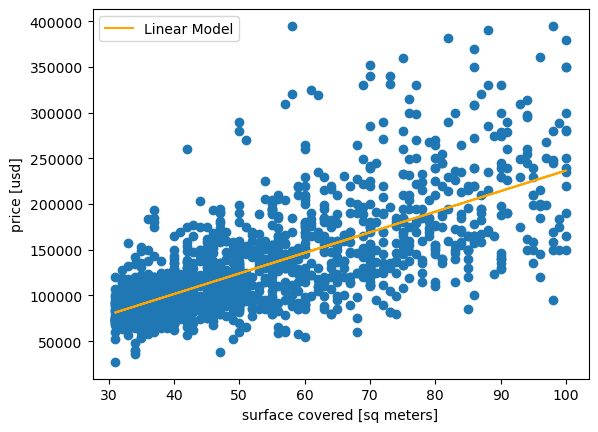

In [30]:
plt.plot(X_train.values, model.predict(X_train), color= "orange", label="Linear Model")
plt.scatter(X_train, y_train)
plt.xlabel("surface covered [sq meters]")
plt.ylabel("price [usd]")
plt.legend();